In [1]:
import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import numpy as np
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 200
import pandas as pd
import seaborn as sns

# BUILD DATA

In [2]:
def make_rdm_seq(lang=1,RDM_SEED=67):
    onehot = F.one_hot(torch.arange(0, 12).view(12,1), num_classes=12)
    
    pa = onehot[0]
    ba = onehot[1]
    ta = onehot[2]
    da = onehot[3]
    
    pi = onehot[4]
    bi = onehot[5]
    ti = onehot[6]
    di = onehot[7]
    
    pu = onehot[8]
    bu = onehot[9]
    tu = onehot[10]
    du = onehot[11]

    setup = np.arange(6)
    data = setup.repeat(500)
    
    rng = np.random.default_rng(RDM_SEED)
    rng.shuffle(data)
    
    data = data[np.insert(np.diff(data).astype(bool), 0, True)] # no back to back repetitions

    if lang==1:
        stims = np.ones((data.shape[0],3,pa.shape[1]))*-1
        stims[np.where(data==0)[0]] = np.vstack((ba,bu,pu))
        stims[np.where(data==1)[0]] = np.vstack((bu,pa,da))
        stims[np.where(data==2)[0]] = np.vstack((du,ta,ba))
        stims[np.where(data==3)[0]] = np.vstack((pa,tu,bi))
        stims[np.where(data==4)[0]] = np.vstack((pi,da,bu))
        stims[np.where(data==5)[0]] = np.vstack((tu,ti,bu))
    elif lang==2:
        stims = np.ones((data.shape[0],3,pa.shape[1]))*-1
        stims[np.where(data==0)[0]] = np.vstack((ta,bu,pu))
        stims[np.where(data==1)[0]] = np.vstack((bu,pa,bi))
        stims[np.where(data==2)[0]] = np.vstack((pa,ta,ba))
        stims[np.where(data==3)[0]] = np.vstack((ti,tu,bi))
        stims[np.where(data==4)[0]] = np.vstack((pi,da,ta))
        stims[np.where(data==5)[0]] = np.vstack((tu,ti,pu))

    syll_vec = {'pa':pa,'ba':ba,'ta':ta,'da':da,'pi':pi,'bi':bi,'ti':ti,'pu':pu,'bu':bu,'tu':tu,'du':du}
    
    return(stims,syll_vec)

def build_data(stims,syll_vec):
    tr_data = np.reshape(stims, (stims.shape[0]*stims.shape[1],stims.shape[2]))
    train_data = tr_data[:1260,:]
    
    stats = np.array(['ii' for i in range(train_data.shape[0])])
    for syll in syll_vec:
        stats[np.where((train_data==syll_vec[syll].numpy()).all(axis=1))]=syll
    df=pd.DataFrame([(x,stats[i+1]) for i,x in enumerate(stats[:-1])],columns=['syll','next_syll'])
    df = df.groupby(df.columns.tolist(),as_index=False).size()
    df['emp_tp'] = np.NaN
    for syll in syll_vec.keys():
        df.loc[df['syll']==syll,'emp_tp'] = df[(df['syll']==syll)]['size'] / df[df['syll']==syll]['size'].sum()
    
    sequential_syllables = np.vstack((train_data[1:,:],np.zeros(12)))
    return(torch.Tensor(train_data),torch.Tensor(sequential_syllables),df)

In [3]:
stims_L1,syll_vec = make_rdm_seq()
train_data,sequential,tp_df = build_data(stims_L1,syll_vec)

# MODEL

In [4]:
class AE(torch.nn.Module):
    def __init__(self):
        super(AE, self).__init__()

        self.encoder = torch.nn.Sequential(
                # torch.nn.Linear(1024,2048),
            # torch.nn.Linear(2048,1024),
            # torch.nn.Linear(1024,512),
            # torch.nn.Linear(512,128),
                torch.nn.Linear(12,128),
                # nn.init.normal_(torch.nn.Linear(12,128).weight, mean=0, std=1.0),
                torch.nn.ReLU(),
                torch.nn.Linear(128,64),
                torch.nn.ReLU(),
                torch.nn.Linear(64,32), # remplace par SITH layer
                torch.nn.ReLU())
        
        
        self.decoder = torch.nn.Sequential(
                torch.nn.Linear(32,64),
                torch.nn.ReLU(),
                torch.nn.Linear(64,128),
                torch.nn.ReLU(),
                torch.nn.Linear(128,12))
                # torch.nn.Softmax())
                # torch.nn.ReLU()
        
    def forward(self,x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return(encoded,decoded)

## Run model

In [5]:
model = AE()
loss_fun = torch.nn.MSELoss()
# loss_fun = torch.nn.
optimizer = torch.optim.Adam(model.parameters())

epochs=200

loss_track = []
# Train
for epoch in range(epochs):
  # Forward
  codes, decoded = model(train_data)

  # Backward
  optimizer.zero_grad()
  loss = loss_fun(decoded, sequential)
  loss_track.append(float(loss))
  loss.backward()
  optimizer.step()

  # Show progress
  # print('[{}/{}] Loss:'.format(epoch+1, epochs), loss.item())

# Save
# torch.save(model.state_dict(), './models/ae_'+str(NUM))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


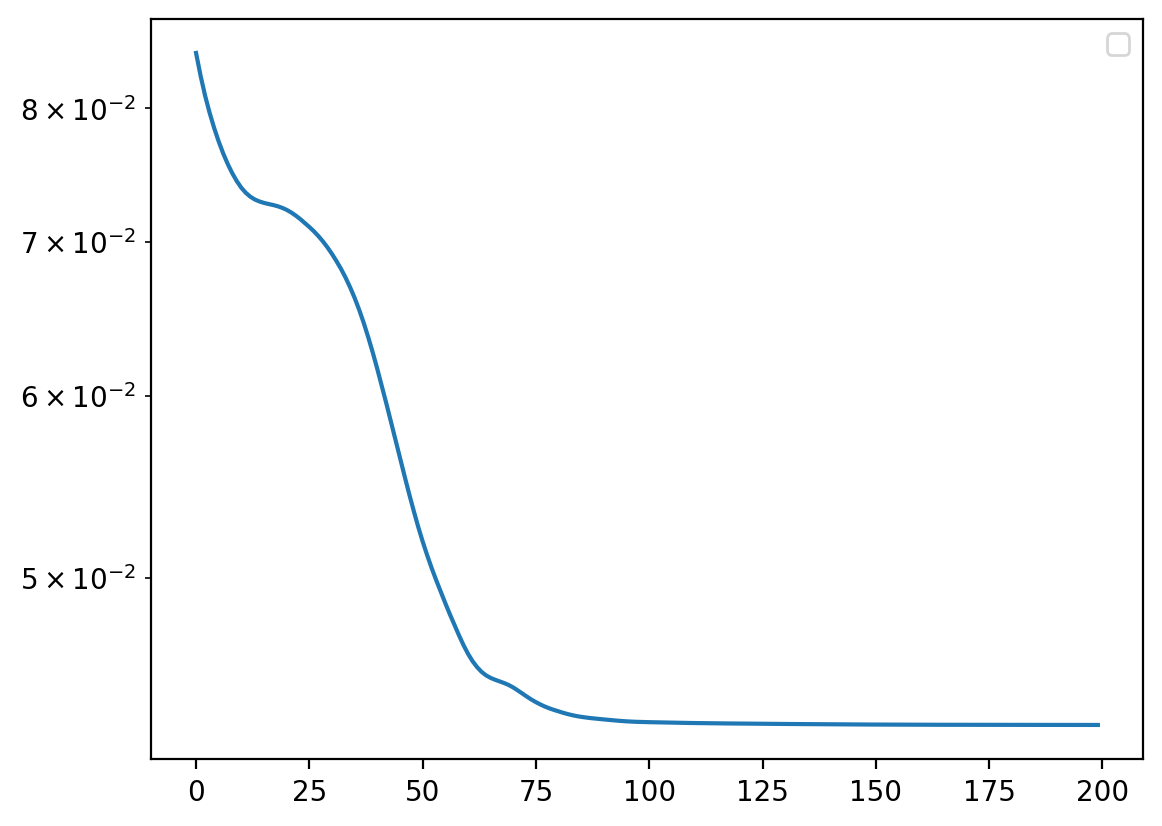

In [6]:
plt.yscale('log')
plt.plot(loss_track)#,label=str(NUM))
plt.legend()
plt.show()

# Calculate TP of all syllables

## Calculate syllable transiton probabilities given each language

Using the rules: $p(a,b) = \sum_c p(a,b,c)$ and $p(a|b)p(b) = p(a,b)$

#### Case 1: probability of 'pu' following 'bu'
'pu' always appears after 'bu', but 'bu' is also followed by 'pa' (in 2nd word) and by 'pi', 'ba', 'tu', 'du' (start syllables of other words)

$p(w1, bu)=\frac{1}{3}\times\frac{1}{6}$

There are 3 syllables in each word and there are 6 words. A syllable can appear only once in a single word.

$p(w1|bu) = \frac{p(w1, bu)}{p(bu)} = \frac{\frac{1}{18}}{\frac{4}{18}}=\frac{1}{4}$
<!-- $p(w2|bu) = \frac{p(w2, bu)}{p(bu)} = \frac{\frac{1}{18}}{\frac{4}{18}}=\frac{1}{4}$
$p(w3|bu) = \frac{p(w3, bu)}{p(bu)} = \frac{\frac{0}{18}}{\frac{4}{18}}=0$
$p(w4|bu) = \frac{p(w4, bu)}{p(bu)} = \frac{\frac{0}{18}}{\frac{4}{18}}=0$
$p(w5|bu) = \frac{p(w5, bu)}{p(bu)} = \frac{\frac{1}{18}}{\frac{4}{18}}=\frac{1}{4}$
$p(w6|bu) = \frac{p(w6, bu)}{p(bu)} = \frac{\frac{1}{18}}{\frac{4}{18}}=\frac{1}{4}$ -->

$P(pu_{n+1} | bu_n) = p(pu | bu, w_1)p(w_1 | bu) + p(pu | bu, w_2)p(w_2|bu) + p(pu | bu, w_3)p(w_3|bu) + p(pu | bu, w_4)p(w_4|bu) + p(pu | bu, w_5)p(w_5|bu) + p(pu | bu, w_6)p(w_6|bu)$

$P(pu | bu) = p(pu | bu, w_1)\frac{1}{4} + p(pu | bu, w_2)\frac{1}{4} + p(pu | bu, w_3)0 + p(pu | bu, w_4)0 + p(pu | bu, w_5)\frac{1}{4} + p(pu | bu, w_6)\frac{1}{4}=1\times\frac{1}{4}+0+0+0+0+0=\frac{1}{4}$

$p(pu | bu, w_1)=1$

$p(pu | bu, w_2)=0$

$p(pu | bu, w_3)=0$

$p(pu | bu, w_4)=0$

$p(pu | bu, w_5)=0$

$p(pu | bu, w_6)=0$


#### Case 2: probability of 'tu' following 'bu'
w1 = [['ba','bu','pu'],['bu','pa','da'],['du','ta','ba'],['pa','tu','bi'],['pi','da','bu'],['tu','ti','bu']]

'tu' can appear after 'bu' as a start syllable of the ending 'bu', but 'bu' is also followed by 'pu', 'pa' (in 1st and 2nd word) and by 'pi', 'ba', 'du', 'bu' (start syllables of other words)

$p(w_i|bu) = \frac{p(w_i, bu)}{p(bu)} = \frac{\frac{1}{18}}{\frac{4}{18}}=\frac{1}{4}$ if $i \in \{1,2,5,6\}$
$p(w_i|bu) = \frac{p(w_i, bu)}{p(bu)} = \frac{\frac{0}{18}}{\frac{4}{18}}=0$ if $i \in \{3,4\}$

$p(tu | bu) = p(tu | bu, w_1)p(w_1 | bu) + p(tu | bu, w_2)p(w_2|bu) + p(tu | bu, w_3)p(w_3|bu) + p(tu | bu, w_4)p(w_4|bu) + p(tu | bu, w_5)p(w_5|bu) + p(tu | bu, w_6)p(w_6|bu)$

$p(tu | bu, w_1)=0$

$p(tu | bu, w_2)=0$

$p(tu | bu, w_3)=0$

$p(tu | bu, w_4)=0$

$p(tu | bu, w_5)=1/5$

$p(tu | bu, w_6)=0$

$p(tu | bu) = p(tu | bu, w_1)\frac{1}{4} + p(tu | bu, w_2)\frac{1}{4} + p(tu | bu, w_3)0 + p(tu | bu, w_4)0 + p(tu | bu, w_5)\frac{1}{4} + p(tu | bu, w_6)\frac{1}{4}=\frac{1}{4} = \frac{1}{4}\times\frac{1}{5} = \frac{1}{20}$

'pu' following 'bu' is 1/4. 'pa' following 'bu' is 1/4. There are 5 initial syllables that can appear after 'pidaBU' which are the other 5 words. Total probabiolity of those is 1/4. There are 5 other initial syllables that can appear after 'tutiBU' which are the other 5 words. Total probabiolity of those is 1/4. Total probability sums to 1.

In [7]:
def get_transitions(w): #,lang=False):
    # syllable_d = {'pa':[],'ba':[],'ta':[],'da':[],'pi':[],'bi':[],'ti':[],'pu':[],'bu':[],'tu':[],'du':[]}
    tp_L = {string:[] for string in syll_vec.keys() if string in np.unique(w)}
    position = {string:[] for string in syll_vec.keys() if string in np.unique(w)}
    start_sylls = []
    end_sylls = []
    for word in w:
        start_sylls.append(word[0])
        end_sylls.append(word[2])
    for j,syll1 in enumerate(tp_L.keys()):
        for k,word in enumerate(w):
            if syll1 in word:
                for i,syll2 in enumerate(word):
                    if syll1 == syll2:
                        if i < 2:
                            tp_L[syll1].append(word[i+1])
                            position[syll1].append(1)
                        # True if we want all the TPs, False if the word initial syllables are not important
                        # which is the case for the test stimuli
                        elif i == 2:
                            # look at all start sylls, EXCEPT those of the word we are in or currently considering
                            for init_w in [x for i,x in enumerate(start_sylls) if i!=k]:  
                                tp_L[syll1].append(init_w)
                                position[syll1].append(0)
        # tp_L[syll1] = list(set(tp_L[syll1]))
    return(tp_L,position,start_sylls,end_sylls)

In [8]:
def get_tp(tp_L,words,position):

    probs = {}
    tp_all = {}
    
    for syll in tp_L:
        probs[syll] = {'n_syll':[],'prob_w_s':[],'in_word':[],'next_syll':[],'tp':[]}
        tp_all[syll] = {'next_syll':[],'tp':[]}
        n_syll = sum(x.count(syll) for x in words)
        probs[syll]['n_syll'].append(n_syll)
    
        for word in words:
            p_ws = word.count(syll)
            # probs[syll]['in_word'].append(p_ws)
            prob = float((p_ws/18) / (n_syll/18))
            probs[syll]['prob_w_s'].append(prob)
            if prob > 0:
                probs[syll]['in_word'] = prob
    
    for syll in tp_L:
        for i,next_syll in enumerate(tp_L[syll]):
            probs[syll]['next_syll'].append(next_syll)
            tp_all[syll]['next_syll'].append(next_syll)
            if position[syll][i] == 1:
                prsnt = 1
                probs[syll]['tp'].append(probs[syll]['in_word'])
                tp_all[syll]['tp'].append(probs[syll]['in_word'])
            else:
                prsnt = 0
                probs[syll]['tp'].append(probs[syll]['in_word']/len(tp_L[syll]))
                if len(tp_L[syll]) <= 7:
                    tp_all[syll]['tp'].append(probs[syll]['in_word']/len(tp_L[syll]))
                else:
                    tp_all[syll]['tp'].append(probs[syll]['in_word']/len(tp_L[syll])*2)
    return(tp_all)


# Test: get results of all possible stimuli

In [9]:
def extract_errors(syll1,syll2,model=model):
    # take two syllables (as torch tensors) and compute MSE between them
    mse = torch.nn.MSELoss()
    syll1 = syll1.to(torch.float32)
    recon = model(syll1)[1]
    mse_r = mse(recon,syll2)
    mse_r = (np.square(recon.detach().numpy() - syll2.detach().numpy())).mean(axis=1)
    # return(recon.detach().numpy(),mse_r.detach().numpy())
    return(recon.detach().numpy(),mse_r[0])


def compare_sylls(syll_vec,trans_p,model=model): #start_sylls,end_sylls,tp_L2,
    # stats = {'syll':[],'next_syll':[],'vec':[],'next_vec':[],'mse':[],'rec':[]}
    stats = {x:{'tp':[],'next_syll':[],'next_vec':[],'rec':[],'mse':[],'eucl':[],'familiar':[]} for x in trans_p.keys()} #'familiar':[]
            
    # look into the interword transitioning syllables
    for i,syll in enumerate(trans_p.keys()):
        for j,next_syll in enumerate(trans_p[syll]['next_syll']):
            tp_syll = trans_p[syll]['tp'][j]
            # if syll in end_sylls:
            #     tp_syll = float(0.75/len(trans_p[syll]))
            # else:
            #     tp_syll = float(1/len(trans_p[syll]))
            stats[syll]['tp'].append(tp_syll)
            stats[syll]['next_syll'].append(next_syll)
            stats[syll]['next_vec'].append(syll_vec[next_syll].detach().numpy()[0,:])
            recon, ms = extract_errors(syll_vec[syll],syll_vec[next_syll],model=model)
            stats[syll]['rec'].append(recon[0,:])
            stats[syll]['mse'].append(ms)
            stats[syll]['eucl'].append(np.linalg.norm(recon[0,:]-syll_vec[next_syll].detach().numpy()[0,:]))
            stats[syll]['familiar'].append(1)
    
        for next_syll in syll_vec.keys():
            if next_syll not in trans_p[syll]['next_syll']:
                stats[syll]['tp'].append(0)
                stats[syll]['familiar'].append(0)
                stats[syll]['next_syll'].append(next_syll)
                stats[syll]['next_vec'].append(syll_vec[next_syll].detach().numpy()[0,:])
                recon, ms = extract_errors(syll_vec[syll],syll_vec[next_syll],model=model)
                stats[syll]['rec'].append(recon[0,:])
                stats[syll]['mse'].append(ms)
                stats[syll]['eucl'].append(np.linalg.norm(recon[0,:]-syll_vec[next_syll].detach().numpy()[0,:]))
                
    return(stats)


def make_df(syll_vec,words,tp_L,position,empirical_tp,model=model):
    TP = get_tp(tp_L,words,position)
    res = compare_sylls(syll_vec,TP,model=model)
    s = pd.DataFrame.from_dict(res,orient='index')
    s['syll'] = s.index
    s.reset_index()
    s = s.explode(['next_syll','mse','rec','next_vec','eucl','tp','familiar'],ignore_index=True)
    
    # s[['mse', 'eucl']] = s[['mse', 'eucl']].apply(pd.to_numeric, errors='coerce').fillna(0)
    s['mse'] = s['mse'].apply(pd.to_numeric, errors='coerce').fillna(0)
    s['eucl'] = s['eucl'].apply(pd.to_numeric, errors='coerce').fillna(0)
    s['tp'] = s['tp'].apply(pd.to_numeric, errors='coerce').fillna(0)
    
    s['pair'] = s['syll'] + '_' + s['next_syll']

    all = empirical_tp.merge(s,how='outer')
    all['emp_tp'] = all['emp_tp'].fillna(0)
    
    return(all)

In [10]:
w1 = [['ba','bu','pu'],['bu','pa','da'],['du','ta','ba'],['pa','tu','bi'],['pi','da','bu'],['tu','ti','bu']]
tp_L1,pos1,start_sylls1,end_sylls1 = get_transitions(w1)

w2 =[['ta','bu','pu'],['bu','pa','bi'],['pa','ta','ba'],['ti','tu','bi'],['pi','da','ta'],['tu','ti','pu']]
tp_L2,pos2,start_sylls2,end_sylls2 = get_transitions(w2)

In [11]:
# for L1
df_L1 = make_df(syll_vec,w1,tp_L1,pos1,tp_df,model=model)

In [12]:
df_L1[df_L1['syll'] == 'pu']

,syll,next_syll,size,emp_tp,tp,next_vec,rec,mse,eucl,familiar,pair
33,pu,bu,15.0,0.223881,0.2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.064418,0.879210,1,pu_bu
34,pu,du,8.0,0.119403,0.2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.080221,0.981150,1,pu_du
35,pu,pa,10.0,0.149254,0.2,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.077193,0.962453,1,pu_pa
36,pu,pi,21.0,0.313433,0.2,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.050475,0.778266,1,pu_pi
37,pu,tu,13.0,0.194030,0.2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.069359,0.912308,1,pu_tu
98,pu,ba,NaN,0.000000,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.102074,1.106744,0,pu_ba
99,pu,ta,NaN,0.000000,0.0,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.101537,1.103831,0,pu_ta
100,pu,da,NaN,0.000000,0.0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.101720,1.104824,0,pu_da
101,pu,bi,NaN,0.000000,0.0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.101745,1.104959,0,pu_bi
102,pu,ti,NaN,0.000000,0.0,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]","[0.1476795, -0.0016042087, 0.0016163453, 0.000...",0.101792,1.105215,0,pu_ti


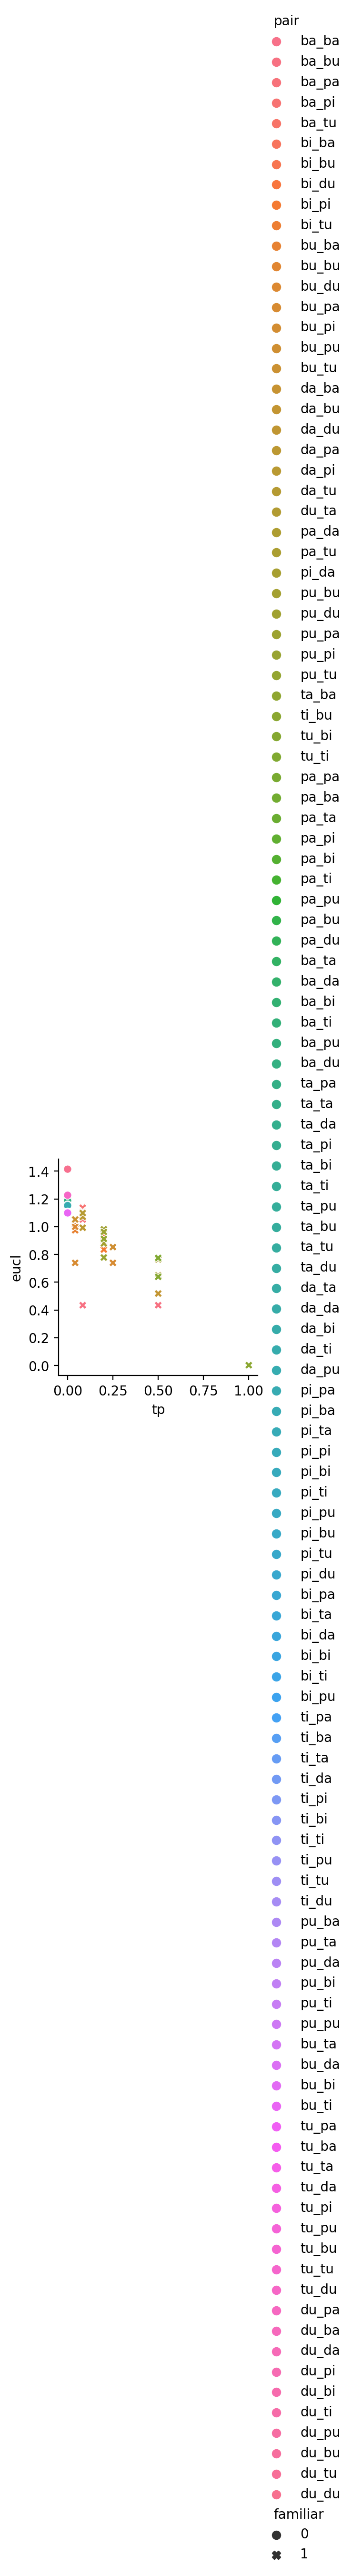

In [13]:
import warnings
warnings.filterwarnings("ignore")

sns.relplot(data=df_L1, x='tp', y='eucl',hue='pair',style='familiar',height=3, aspect=1)


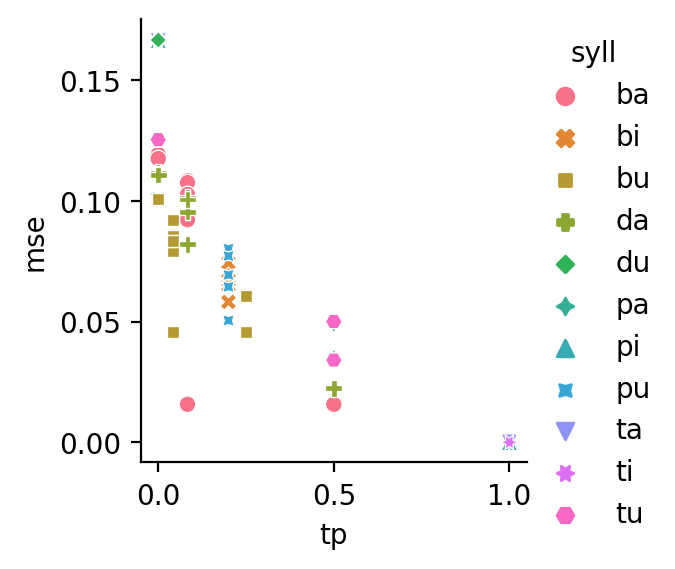

In [15]:
import warnings
warnings.filterwarnings("ignore")

sns.relplot(data=df_L1, x='tp', y='mse',hue='syll',style='syll',height=3, aspect=1)


---
# Streamline the process for 10 separate models with 10 separate data
---

In [ ]:
# Language 1, babupu, bupada, dutaba, patubi, pidabu, tutibu
# Language 2: tabupu, bupabi, pataba, titubi, pidata, tutipu

In [16]:
w1 = [['ba','bu','pu'],['bu','pa','da'],['du','ta','ba'],['pa','tu','bi'],['pi','da','bu'],['tu','ti','bu']]
w2 =[['ta','bu','pu'],['bu','pa','bi'],['pa','ta','ba'],['ti','tu','bi'],['pi','da','ta'],['tu','ti','pu']]

In [21]:
results = []
for n in range(10):
    stims_L1,syll_vec = make_rdm_seq(lang=1,RDM_SEED=n)
    train_data,sequential,empirical_tp1 = build_data(stims_L1,syll_vec)
    # make 10 initializations for each dataset
    for m in range(10):        
        model = AE()
        loss_fun = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters())
        epochs=200
        
        loss_track = []
        # Train
        for epoch in range(epochs):
          # Forward
          codes, decoded = model(train_data)
          # Backward
          optimizer.zero_grad()
          loss = loss_fun(decoded, sequential)
          loss_track.append(float(loss))
          loss.backward()
          optimizer.step()
        
        tp_L1,pos1,start_sylls1,end_sylls1 = get_transitions(w1)
        df_L1 = make_df(syll_vec,w1,tp_L1,pos1,empirical_tp1,model=model)
        df_L1['n_data'] = n
        df_L1['n_model'] = m
    
        results.append(df_L1)

iters1 = pd.concat(results)

In [23]:
iters1[iters1.pair == 'ba_ba']

,syll,next_syll,size,emp_tp,tp,next_vec,rec,mse,eucl,familiar,pair,n_data,n_model
0,ba,ba,12.0,0.090226,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.0602071, 0.09007868, -0.00020066649, -0.000...",0.104904,1.121985,1,ba_ba,0,0
0,ba,ba,12.0,0.090226,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.05707316, 0.093392245, -0.0018332768, 0.004...",0.104279,1.118636,1,ba_ba,0,1
0,ba,ba,12.0,0.090226,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.060509525, 0.090654254, 0.00012396462, 5.82...",0.104850,1.121694,1,ba_ba,0,2
0,ba,ba,12.0,0.090226,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.071446605, 0.09424971, -0.0043539405, 0.000...",0.104420,1.119391,1,ba_ba,0,3
0,ba,ba,12.0,0.090226,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.05984129, 0.089634344, -0.0003694184, -0.00...",0.104936,1.122155,1,ba_ba,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,ba,ba,14.0,0.100719,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.11577784, 0.10078052, -0.00020617619, 0.001...",0.101614,1.104248,1,ba_ba,9,5
0,ba,ba,14.0,0.100719,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.114744134, 0.10039444, -0.00036340393, -0.0...",0.101605,1.104201,1,ba_ba,9,6
0,ba,ba,14.0,0.100719,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.11443964, 0.100725956, -0.0011532307, -0.00...",0.101425,1.103221,1,ba_ba,9,7
0,ba,ba,14.0,0.100719,0.083333,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.115226045, 0.10111362, -0.00020764768, -0.0...",0.101494,1.103597,1,ba_ba,9,8


In [32]:
iters1.to_csv('stat_results_l1.csv')

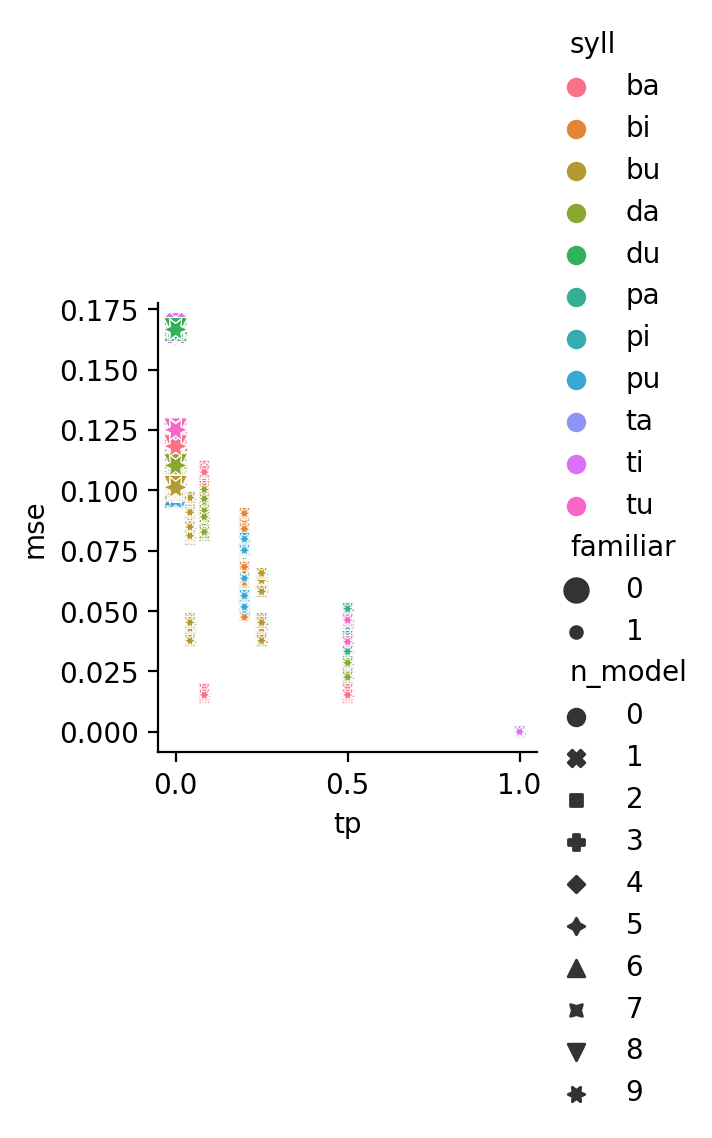

In [26]:
sns.relplot(data=iters1, x='tp', y='mse',hue='syll',style='n_model',size='familiar',height=3, aspect=1)

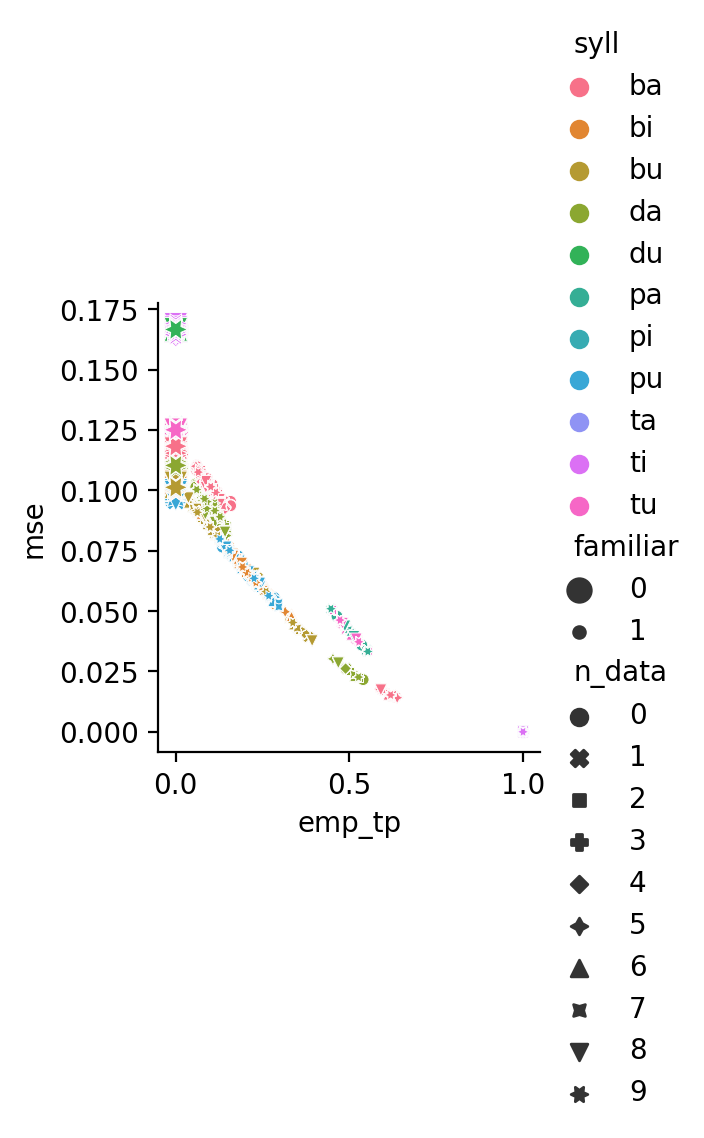

In [30]:
sns.relplot(data=iters1, x='emp_tp', y='mse',hue='syll',style='n_data',size='familiar',height=3, aspect=1)

In [31]:
results2 = []
for n in range(10):
    stims_L2,syll_vec = make_rdm_seq(lang=2,RDM_SEED=n)
    train_data,sequential,empirical_tp2 = build_data(stims_L2,syll_vec)
    for m in range(10):
        model = AE()
        loss_fun = torch.nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters())
        epochs=200
        
        loss_track = []
        # Train
        for epoch in range(epochs):
          # Forward
          codes, decoded = model(train_data)
          # Backward
          optimizer.zero_grad()
          loss = loss_fun(decoded, sequential)
          loss_track.append(float(loss))
          loss.backward()
          optimizer.step()
        
        tp_L2,pos2,start_sylls2,end_sylls2 = get_transitions(w2)
        df_L2 = make_df(syll_vec,w2,tp_L2,pos2,empirical_tp2,model=model)
        df_L2['n_data'] = n
        df_L2['n_model'] = m
    
        results2.append(df_L2)
    
iters2 = pd.concat(results2)

In [36]:
iters2.to_csv('stat_results_l2.csv')

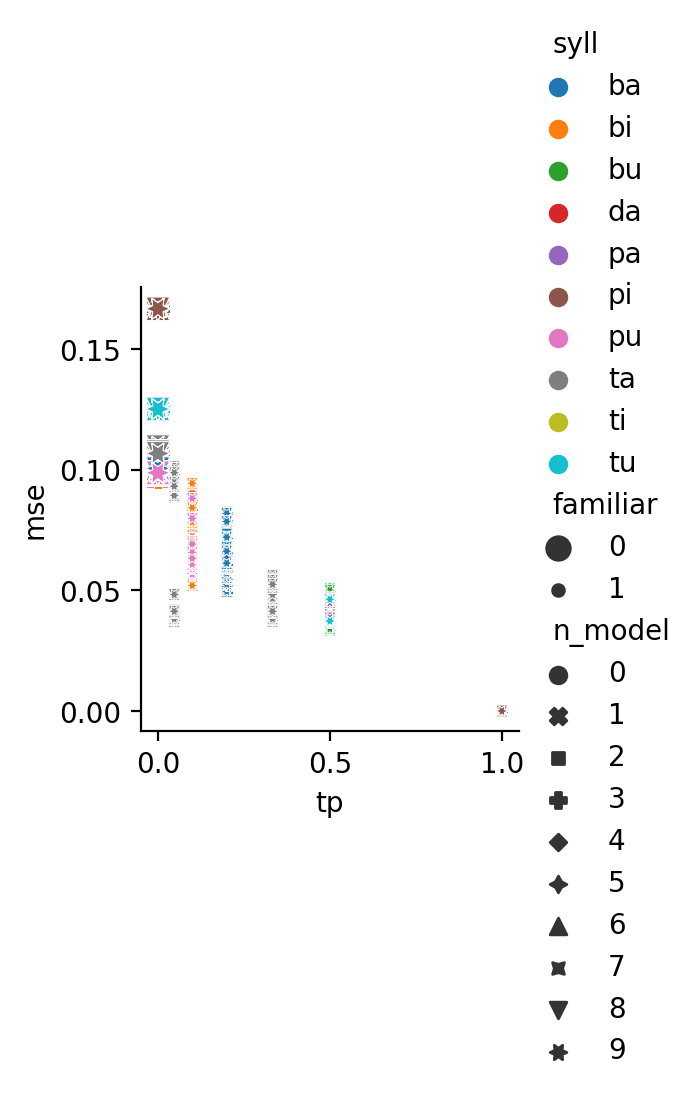

In [33]:
sns.relplot(data=iters2, x='tp', y='mse',hue='syll',style='n_model',size='familiar',height=3, aspect=1) #[iters2.syll=='pi']

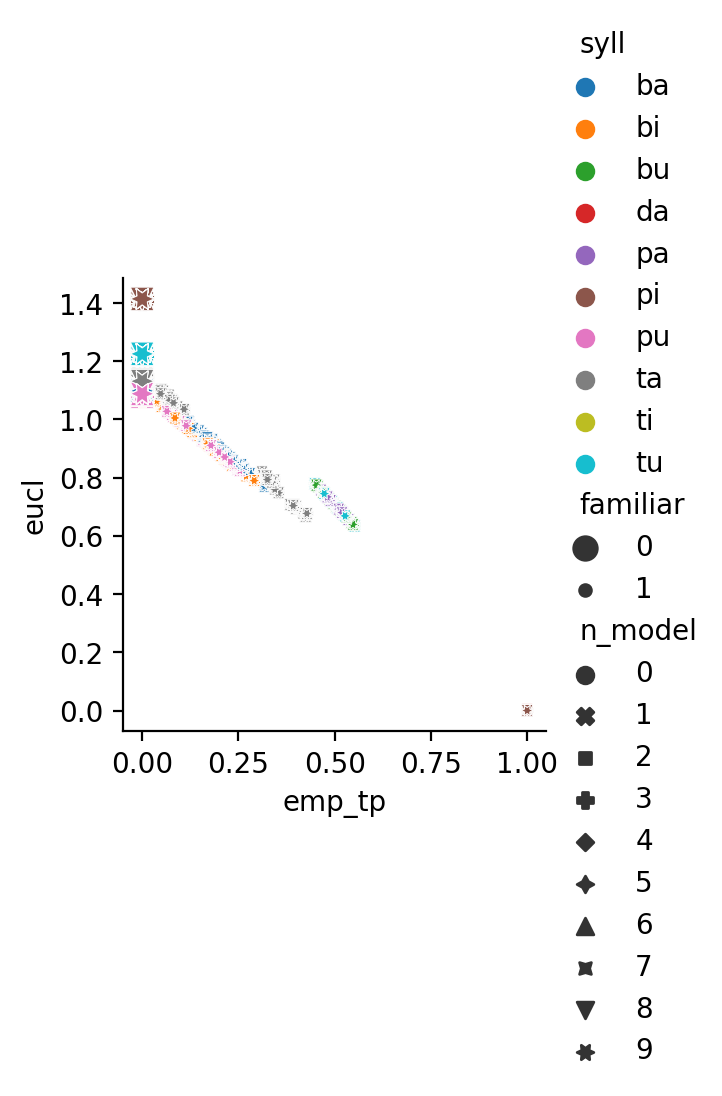

In [34]:
sns.relplot(data=iters2, x='emp_tp', y='eucl',hue='syll',style='n_model',size='familiar',height=3, aspect=1) #[iters2.syll=='pi']

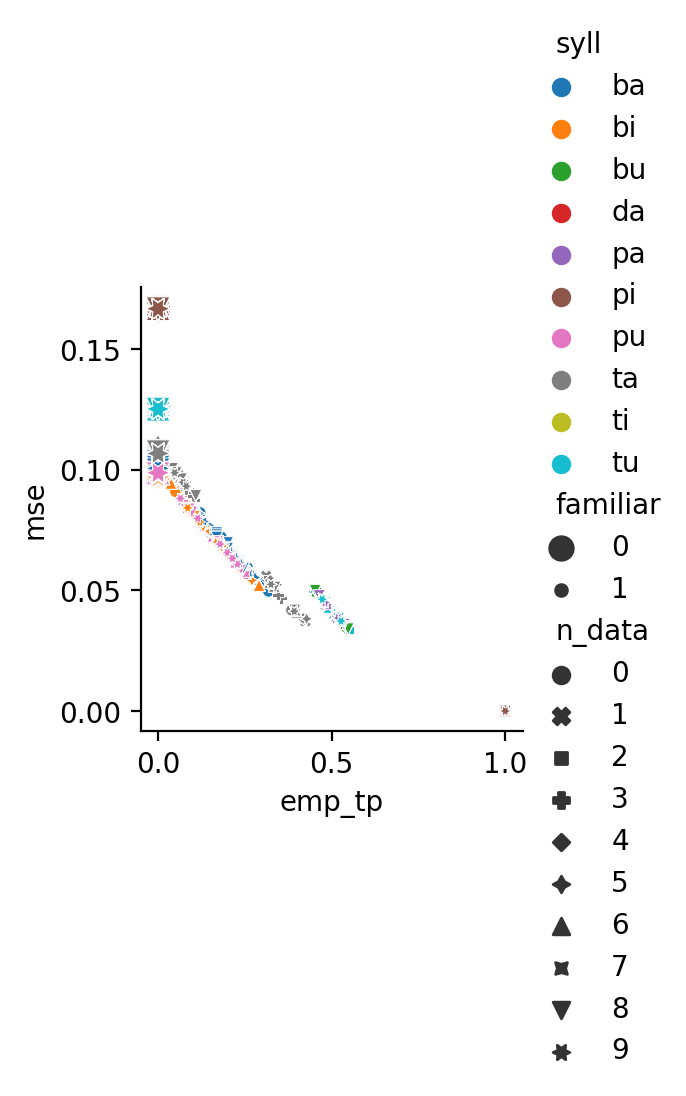

In [35]:
sns.relplot(data=iters2, x='emp_tp', y='mse',hue='syll',style='n_data',size='familiar',height=3, aspect=1) #[iters2.syll=='pi']